[![OpenSD2026 - Belgium](../../assets/OpenSD_bannerlogo.jpg)](https://www.vub.be/en/event/opensd-summer-school-belgium)

Copyright © 2026 OpenSD2026 contributors. All rights reserved. The materials in this repository are provided for educational use only and may not be copied, redistributed, or modified without prior permission. See [LICENSE](../../LICENSE).

# *Outlines*

<img src="../../assets/Flowchart_FatigueAssessment.png" width="700">

# **Introduction**

We will be using loads from [WILLOW Norther Open Source Dataset](https://zenodo.org/records/11093262) for conducting this workshop

<img src="../../assets/Fig1_Norther_locaction.png" width="800">



There are various sensors installed on this turbine including accelerometers, strain gauges, fiber bragg gratings (FBGs)


<img src="../../assets/Sensor_Channels.png" width="700">


The list of SCADA parameters and the intervals for which the data is avaliable is also given as follows:

<img src="../../assets/SCADA_Operational_Data.png" width="500">



# *Loading Necessary Packages*

In [1]:
import warnings
warnings.filterwarnings('ignore')
import gc

# Packages for handling and processing load data
import pandas as pd
import numpy as np
from tqdm import tqdm
tqdm.pandas() 

# Importing py_fatigue for load signals processing, fatigue damage and crack growth calculations
import py_fatigue as pf


#Packages for Plotting
import plotly.graph_objects as go
import matplotlib.pyplot as plt
import matplotlib.dates as mdates


# Defining SN-Curve

findfont: Failed to find font weight semibold, now using 700.


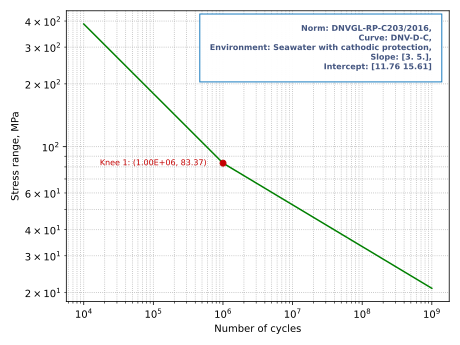

In [2]:
sn_cp = pf.SNCurve(
    slope=[3., 5.], 
    intercept=[11.764, 15.606], 
    environment = 'Seawater with cathodic protection', 
    curve = 'DNV-D-C', 
    norm ='DNVGL-RP-C203/2016',
    color='g'
)

sn_cp

# *Fatigue Damage Calculation*

In [4]:
deg230_data = pd.read_pickle("deg230_data.pkl")

In [5]:
LEF = 3
SEF = 0.8
scale_f = 1.15
SCF_in = 1.1
material_SF = 1.25

damage_Factor = LEF*SEF*SCF_in*scale_f*material_SF

print(damage_Factor)

3.795000000000001


In [6]:
cc = deg230_data.iloc[0,0]

In [7]:
scaled_cc = cc*damage_Factor
scaled_cc

,"TP_SG_LAT014_DEG230_0_nr1 [MPa], SCF=3.795000000000001"
Cycle counting object,
"largest full stress range, MPa",30.322138
"largest stress range, MPa",36.247994
number of full cycles,251
number of residuals,22
number of small cycles,0
stress concentration factor,3.795
residuals resolved,False
mean stress-corrected,No


In [8]:
fat_dmg = pf.damage.stress_life.get_pm(scaled_cc, sn_cp)

In [9]:
fat_dmg.sum()

np.float64(9.29690852230764e-08)

In [10]:
for col in deg230_data.columns:
    if 'CC_' in col:
        damage_col = col + " Damage"
        deg230_data[damage_col] = deg230_data[col].progress_apply(
            lambda cc: (
                sum(pf.damage.stress_life.get_pm(cc * damage_Factor, sn_cp))
                if cc is not None and not isinstance(cc, float) else np.nan
            )
        )


100%|██████████| 22/22 [00:00<00:00, 3684.65it/s]


In [11]:
deg230_data

,CC_TP_SG_LAT014_DEG230_0_nr1 [MPa],case_ID,CC_TP_SG_LAT014_DEG230_0_nr1 [MPa] Damage
2020-07-03 01:30:00+00:00,CC_TP_SG_LAT014_DEG230_0_nr1 [MPa] (03 Jul 202...,parked,9.296909e-08
2020-07-03 01:40:00+00:00,CC_TP_SG_LAT014_DEG230_0_nr1 [MPa] (03 Jul 202...,parked,1.204587e-07
2020-07-03 01:50:00+00:00,CC_TP_SG_LAT014_DEG230_0_nr1 [MPa] (03 Jul 202...,parked,1.529326e-07
2020-07-03 02:00:00+00:00,CC_TP_SG_LAT014_DEG230_0_nr1 [MPa] (03 Jul 202...,parked,1.081532e-07
2020-07-03 02:10:00+00:00,CC_TP_SG_LAT014_DEG230_0_nr1 [MPa] (03 Jul 202...,parked,4.078044e-09
2020-07-03 02:20:00+00:00,CC_TP_SG_LAT014_DEG230_0_nr1 [MPa] (03 Jul 202...,parked,1.561001e-08
2020-07-03 02:30:00+00:00,CC_TP_SG_LAT014_DEG230_0_nr1 [MPa] (03 Jul 202...,parked,5.149518e-09
2020-07-03 02:40:00+00:00,CC_TP_SG_LAT014_DEG230_0_nr1 [MPa] (03 Jul 202...,parked,2.334683e-08
2020-07-03 02:50:00+00:00,CC_TP_SG_LAT014_DEG230_0_nr1 [MPa] (03 Jul 202...,parked,9.890900e-09
2020-07-03 03:00:00+00:00,CC_TP_SG_LAT014_DEG230_0_nr1 [MPa] (03 Jul 202...,parked,1.637489e-08


In [16]:
deg230_data['CC_TP_SG_LAT014_DEG230_0_nr1 [MPa] Damage']

2020-07-03 01:30:00+00:00    9.296909e-08
2020-07-03 01:40:00+00:00    1.204587e-07
2020-07-03 01:50:00+00:00    1.529326e-07
2020-07-03 02:00:00+00:00    1.081532e-07
2020-07-03 02:10:00+00:00    4.078044e-09
2020-07-03 02:20:00+00:00    1.561001e-08
2020-07-03 02:30:00+00:00    5.149518e-09
2020-07-03 02:40:00+00:00    2.334683e-08
2020-07-03 02:50:00+00:00    9.890900e-09
2020-07-03 03:00:00+00:00    1.637489e-08
2020-07-03 03:10:00+00:00    7.013451e-09
2020-07-05 22:40:00+00:00    2.178268e-07
2020-07-05 22:50:00+00:00    4.917126e-07
2020-07-05 23:00:00+00:00    6.755194e-07
2020-07-05 23:10:00+00:00    9.159950e-07
2020-07-05 23:20:00+00:00    5.586092e-07
2020-07-05 23:30:00+00:00    4.702798e-07
2020-07-05 23:40:00+00:00    4.956402e-07
2020-07-05 23:50:00+00:00    8.284528e-07
2020-07-06 00:00:00+00:00    9.048458e-07
2020-07-06 00:10:00+00:00    5.276210e-07
2020-07-06 00:20:00+00:00    5.734131e-07
Name: CC_TP_SG_LAT014_DEG230_0_nr1 [MPa] Damage, dtype: float64

In [17]:
deg230_data['cumulative damage'] = deg230_data['CC_TP_SG_LAT014_DEG230_0_nr1 [MPa] Damage'].cumsum()
deg230_data

,CC_TP_SG_LAT014_DEG230_0_nr1 [MPa],case_ID,CC_TP_SG_LAT014_DEG230_0_nr1 [MPa] Damage,cumulative damage
2020-07-03 01:30:00+00:00,CC_TP_SG_LAT014_DEG230_0_nr1 [MPa] (03 Jul 202...,parked,9.296909e-08,9.296909e-08
2020-07-03 01:40:00+00:00,CC_TP_SG_LAT014_DEG230_0_nr1 [MPa] (03 Jul 202...,parked,1.204587e-07,2.134278e-07
2020-07-03 01:50:00+00:00,CC_TP_SG_LAT014_DEG230_0_nr1 [MPa] (03 Jul 202...,parked,1.529326e-07,3.663604e-07
2020-07-03 02:00:00+00:00,CC_TP_SG_LAT014_DEG230_0_nr1 [MPa] (03 Jul 202...,parked,1.081532e-07,4.745137e-07
2020-07-03 02:10:00+00:00,CC_TP_SG_LAT014_DEG230_0_nr1 [MPa] (03 Jul 202...,parked,4.078044e-09,4.785917e-07
2020-07-03 02:20:00+00:00,CC_TP_SG_LAT014_DEG230_0_nr1 [MPa] (03 Jul 202...,parked,1.561001e-08,4.942017e-07
2020-07-03 02:30:00+00:00,CC_TP_SG_LAT014_DEG230_0_nr1 [MPa] (03 Jul 202...,parked,5.149518e-09,4.993512e-07
2020-07-03 02:40:00+00:00,CC_TP_SG_LAT014_DEG230_0_nr1 [MPa] (03 Jul 202...,parked,2.334683e-08,5.226981e-07
2020-07-03 02:50:00+00:00,CC_TP_SG_LAT014_DEG230_0_nr1 [MPa] (03 Jul 202...,parked,9.890900e-09,5.325890e-07
2020-07-03 03:00:00+00:00,CC_TP_SG_LAT014_DEG230_0_nr1 [MPa] (03 Jul 202...,parked,1.637489e-08,5.489639e-07


Plot the cumulative damage with time to see the damage accumulation rates

[]

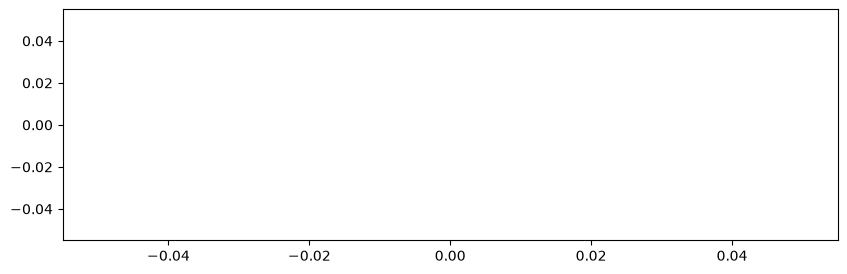

In [18]:
plt.figure(figsize=(10,3))
plt.plot()

In [19]:
# Synthetic timeline
n_steps = len(deg230_data)
new_index = pd.date_range(start="2020-07-03 01:30:00+00:00", periods=n_steps, freq="10min")
deg230_data = deg230_data.set_index(new_index)

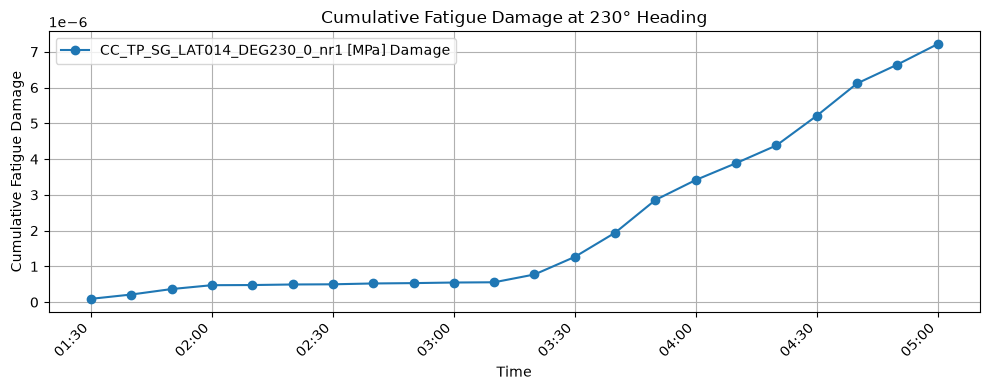

In [20]:
damage_cols = [c for c in deg230_data.columns if "Damage" in c]


deg230_data['cumulative damage'] = deg230_data[damage_cols].cumsum()

# --- Plot ---
fig, ax = plt.subplots(figsize=(10, 4))

for col in damage_cols:
    ax.plot(deg230_data.index, deg230_data['cumulative damage'], label=col, marker='o', linestyle='-')

# Format the x-axis
ax.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))    # show only hour:minute


plt.setp(ax.get_xticklabels(), rotation=45, ha='right')

ax.set_xlabel("Time")
ax.set_ylabel("Cumulative Fatigue Damage")
ax.set_title("Cumulative Fatigue Damage at 230° Heading")
ax.legend()
ax.grid(True)
plt.tight_layout()
plt.show()


In [21]:
OS_dmg_mean = deg230_data.groupby('case_ID')['CC_TP_SG_LAT014_DEG230_0_nr1 [MPa] Damage'].mean()
OS_dmg_mean

case_ID
parked    5.054339e-08
rated     6.054469e-07
Name: CC_TP_SG_LAT014_DEG230_0_nr1 [MPa] Damage, dtype: float64

## **Fatigue Lifetime Estimation**

fatigue life can be estimated as the inverse of Yearly fatige damage

In [22]:
1/(365*24*6*OS_dmg_mean['rated'])

np.float64(31.42451568047989)

In [23]:
1/(365*24*6*OS_dmg_mean['parked'])

np.float64(376.4265566075872)

We can assume proportions of operational conditions for further analysis, we can play with these two operational states to see their effects on the lifetime

In [24]:
prob_parked = 0.2
prob_rated = 1-prob_parked

In [25]:
yearly_damage = prob_rated*(365*24*6*OS_dmg_mean['rated']) + prob_parked*(365*24*6*OS_dmg_mean['parked'])
1/yearly_damage

np.float64(38.47760605717978)

# Crack Growth Calculations

In [26]:
t = 80.0
d = 6.50*1000
crack_depth = 1.5

HollowCylinder(
  _id=HOL_CYL_01,
  initial_depth=1.5,
  outer_diameter=6500.0,
  thickness=80.0,
  height=100.0,
  width_to_depth_ratio=2.0,
  crack_position=external,
)

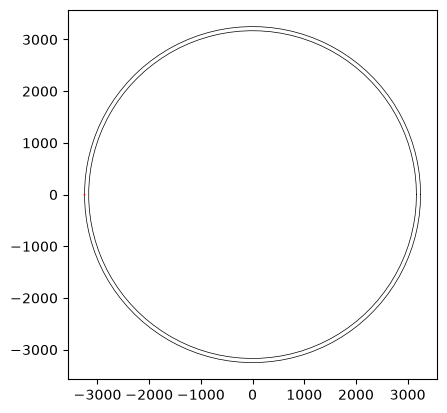

In [27]:
geo = pf.geometry.HollowCylinder(
  initial_depth=crack_depth,
  thickness=t,
  height=100.,
  outer_diameter=d,
  crack_position="external"
)
geo.plot()
geo

(<Figure size 640x480 with 1 Axes>,
 <Axes: xlabel='SIF range (ΔK), MPa √mm', ylabel='Crack growth rate (da/dN), mm/cycle'>)

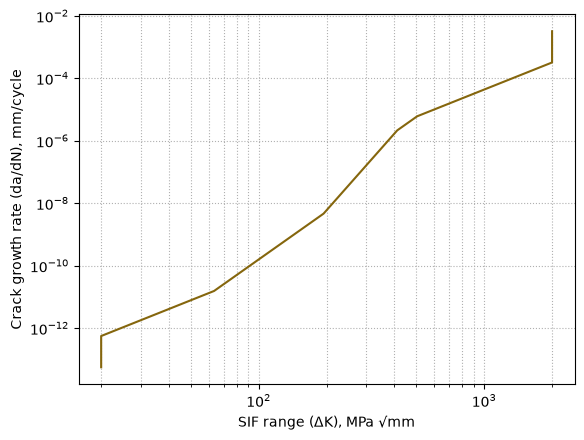

In [29]:
SIF = np.linspace(1,2500, 300)
SLOPE = np.array([2.88, 5.1, 8.16, 5.1, 2.88])
INTER = np.array([1E-16, 1E-20, 1E-27, 1E-19, 1E-13])
THRESHOLD = 20
CRITICAL = 2000
pc = pf.ParisCurve(slope=SLOPE, intercept=INTER, threshold=THRESHOLD,
                   critical=CRITICAL, norm="The norm",
                   environment="Environment", curve="nr.")
pc.plot()


In [30]:
cg_d = pf.damage.crack_growth.get_crack_growth(
  scaled_cc, pc, geo, express_mode=True
)
print(f"Cycles to end: {int(cg_d.final_cycles)}")

Fatigue spectrum applied w/o failure. Stopping calculation
Cycles to end: 262


In [31]:
cg_d.crack_depth.max()

np.float64(1.5000000002055345)

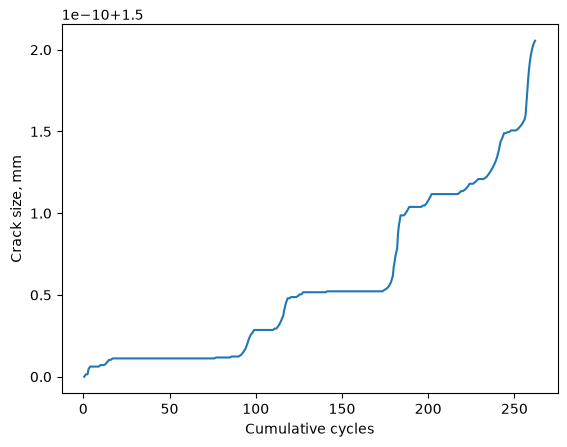

In [32]:
plt.plot(np.cumsum(cg_d.count_cycle), cg_d.crack_depth)
plt.xlabel("Cumulative cycles")
plt.ylabel("Crack size, mm")
plt.show()

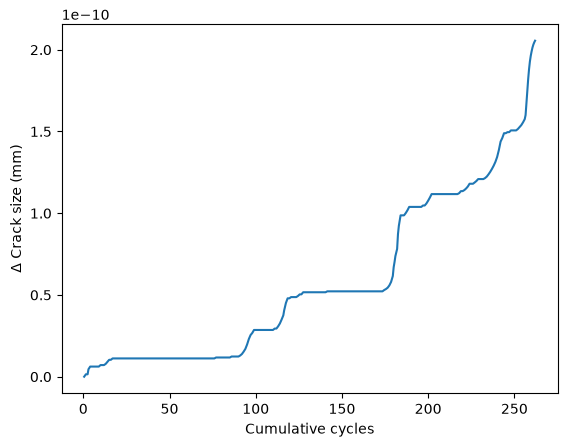

In [33]:
plt.plot(np.cumsum(cg_d.count_cycle),
         cg_d.crack_depth - cg_d.crack_depth[0])

plt.xlabel("Cumulative cycles")
plt.ylabel("Δ Crack size (mm)")   # shows relative growth
plt.show()